In [1]:
import matplotlib.pyplot as plt
import scienceplots  # This is required to register the styles
import numpy as np
import pickle

# Verify your numpy version
print(f"Using NumPy version: {np.__version__}") 

#plt.style.use(['science', 'ieee']) # Example of using the ieee style (readable figures in black&white print). Nature style is also nice for presentations - uses the sans-serif fonts.
plt.style.use(['science', 'notebook', 'no-latex'])


Using NumPy version: 1.26.4


In [3]:
with open('clara_pvMesh_benchmark_results_0.pkl', 'rb') as f:
    results = pickle.load(f)

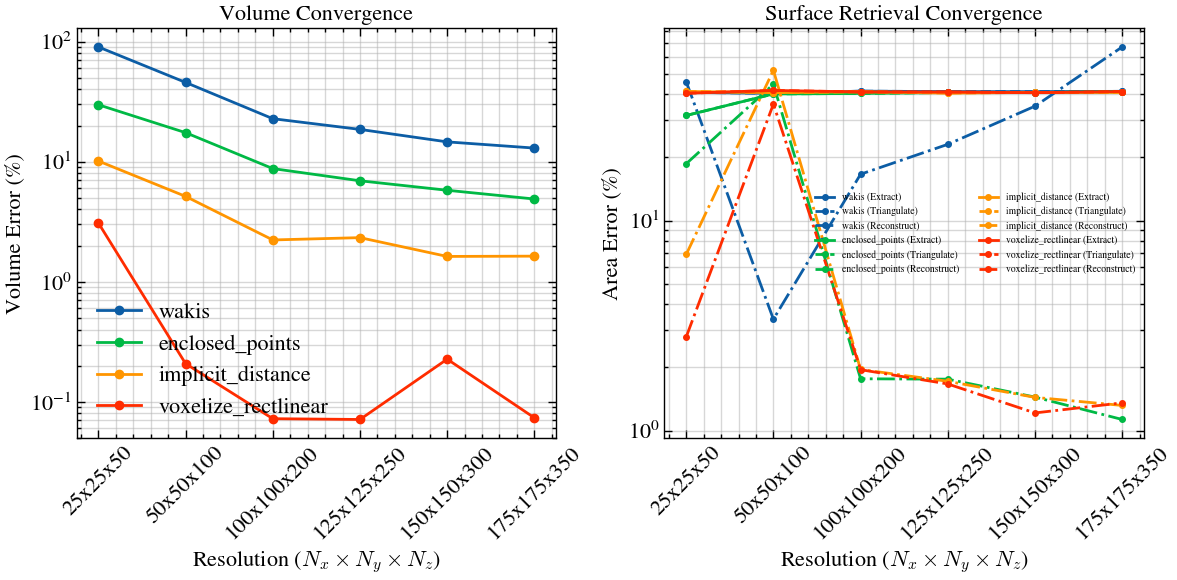

In [4]:
sub_methods = ['Extract', 'Triangulate', 'Reconstruct']
line_styles = ['-', '--', '-.']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results.items():
    # Sort resolutions
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')))
    
    # 1. Volume Plot (Standard line)
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    # Grab the color of the first plot to reuse it for the area lines
    p = ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    current_color = p[0].get_color() 
    
    # 2. Area Plot (Multi-line)
    # res_dict[r]['area_err'] is expected to be a list/array of 3 values
    for i in range(3):
        errors_area = [res_dict[r]['area_err'][i] for r in sorted_resolutions]
        
        # Only add to legend if it's the first method to avoid duplicate labels
        label = f"{method} ({sub_methods[i]})"
        
        ax[1].plot(sorted_resolutions, errors_area, 
                   color=current_color, 
                   linestyle=line_styles[i], 
                   marker='o', 
                   markersize=4,
                   label=label)
        
for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Retrieval Convergence')
# Place legend outside if it gets too crowded
ax[1].legend(fontsize='x-small', ncol=2)

plt.tight_layout()
plt.show()

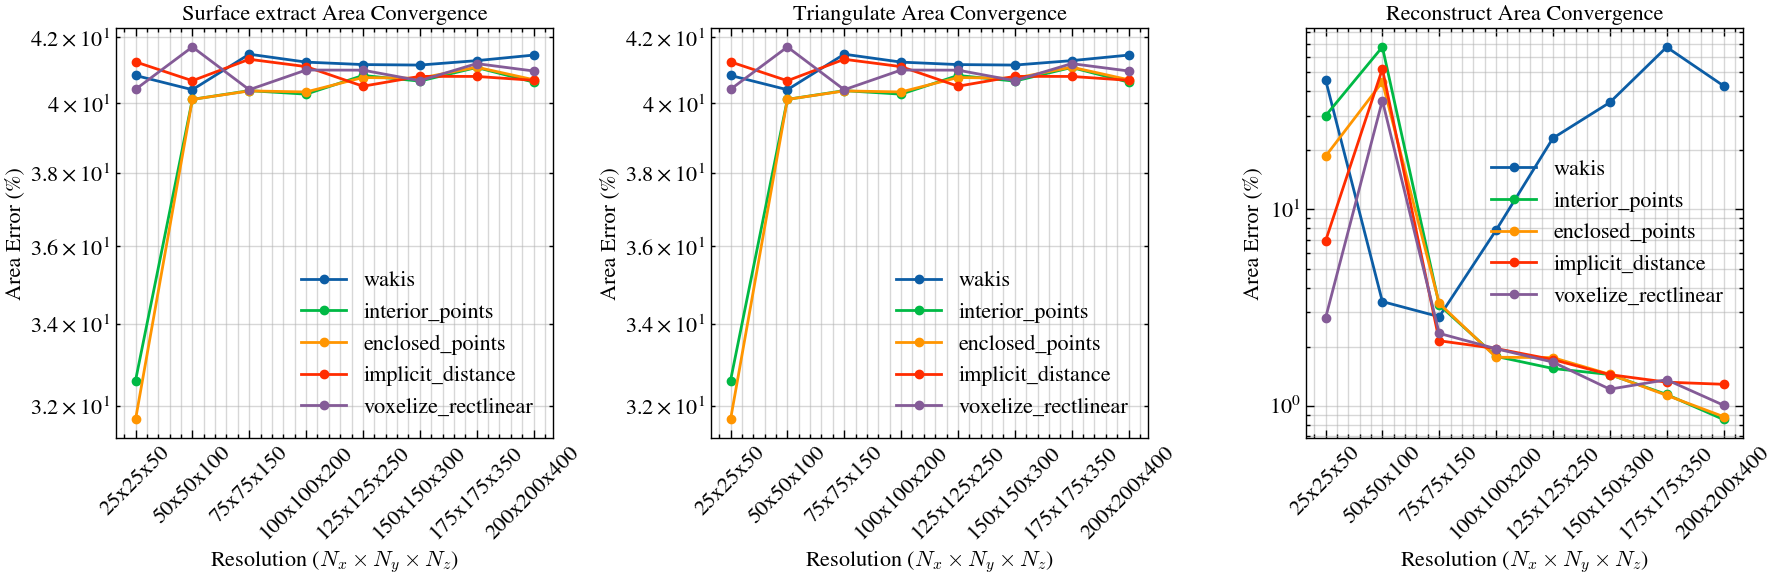

In [5]:
with open('clara_pvMesh_benchmark_results_1.pkl', 'rb') as f:
    results1 = pickle.load(f)


fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for method, res_dict in results1.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    #errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    #ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract_0 = [res_dict[r]['area_err'][0] for r in sorted_resolutions]
    ax[0].plot(sorted_resolutions, errors_extract_0, marker='o', label=method)
    errors_extract_1 = [res_dict[r]['area_err'][1] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract_1, marker='o', label=method)
    errors_extract_2 = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[2].plot(sorted_resolutions, errors_extract_2, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)


ax[0].set_ylabel('Area Error (%)')
ax[1].set_ylabel('Area Error (%)')
ax[2].set_ylabel('Area Error (%)')
ax[0].set_title('Surface extract Area Convergence')
ax[1].set_title('Triangulate Area Convergence')
ax[2].set_title('Reconstruct Area Convergence')

# Place legend outside if it gets too crowded
ax[0].legend()
ax[1].legend()
ax[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

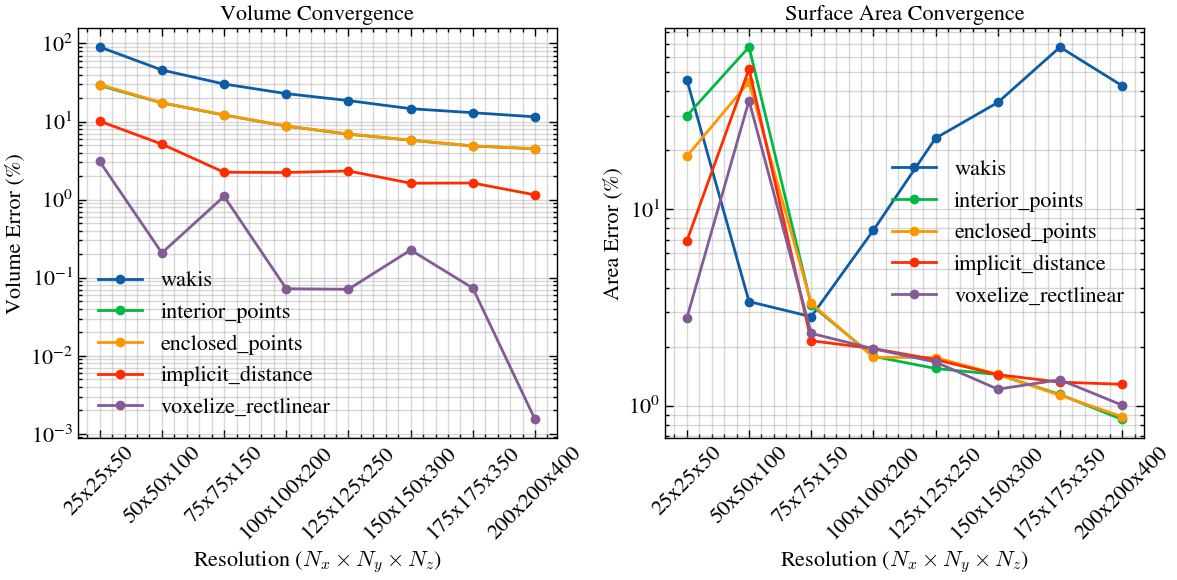

In [6]:
with open('clara_pvMesh_benchmark_results_1.pkl', 'rb') as f:
    results1 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results1.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_2-stltol&interiormethod.pkl', 'rb') as f:
    results2 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in {k: v for k, v in results2.items() if k != 'interior_points'}.items():
for method, res_dict in {k: v for k, v in results2.items()}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_3.pkl', 'rb') as f:
    results3 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results3.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_4.pkl', 'rb') as f:
    results4 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results4.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_5.pkl', 'rb') as f:
    results5 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results5.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_5_test0.pkl', 'rb') as f:
    results50 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results50.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6.pkl', 'rb') as f:
    results6 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results6.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6_test0.pkl', 'rb') as f:
    results60 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results60.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6_test1.pkl', 'rb') as f:
    results61 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results61.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6_test2.pkl', 'rb') as f:
    results62 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results62.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_6_test4.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_6_test6.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_6_test60.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_8_test0.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

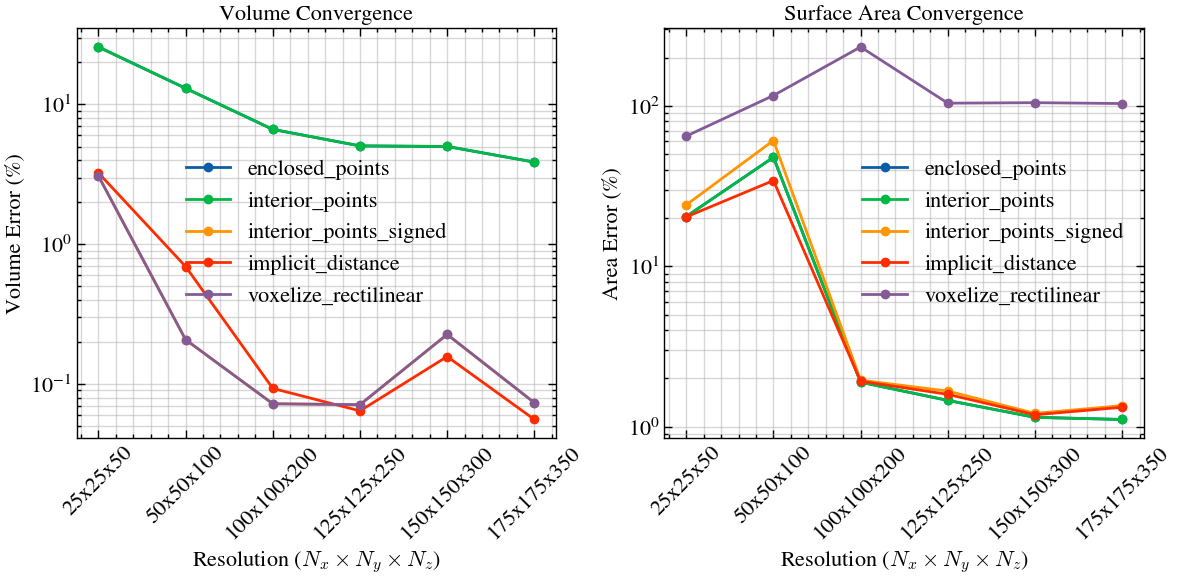

In [10]:
import pickle 

with open('clara_pvMesh_benchmark_results_8_test0.pkl', 'rb') as f:
    results8= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results8.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

# The Fingers

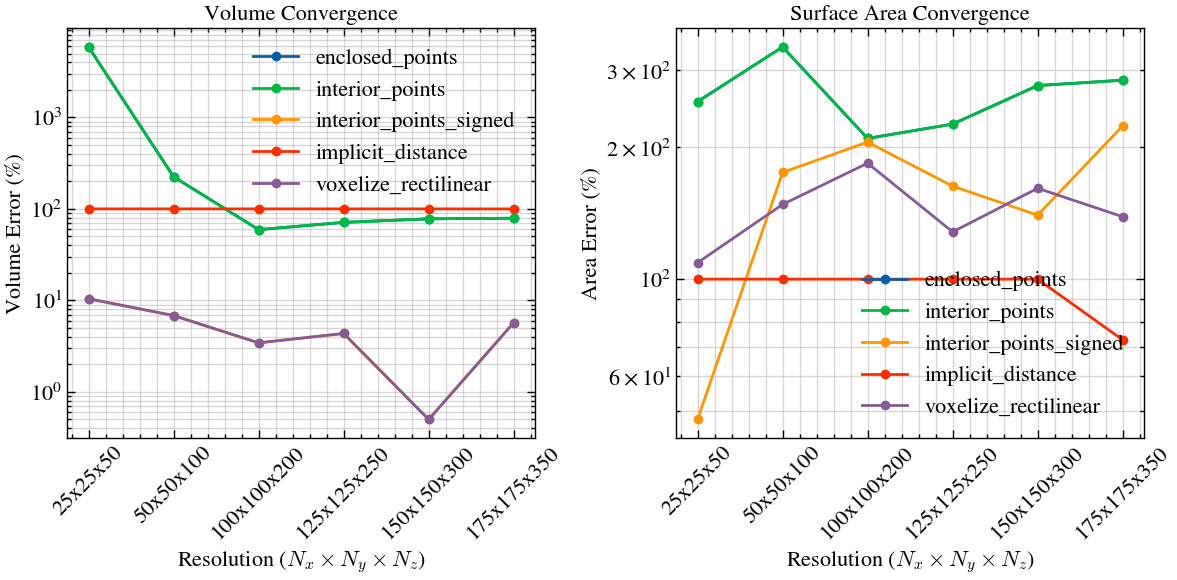

In [8]:

with open('clara_pvMesh_bench_finger_res_0.pkl', 'rb') as f:
    results_finger0= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger0.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

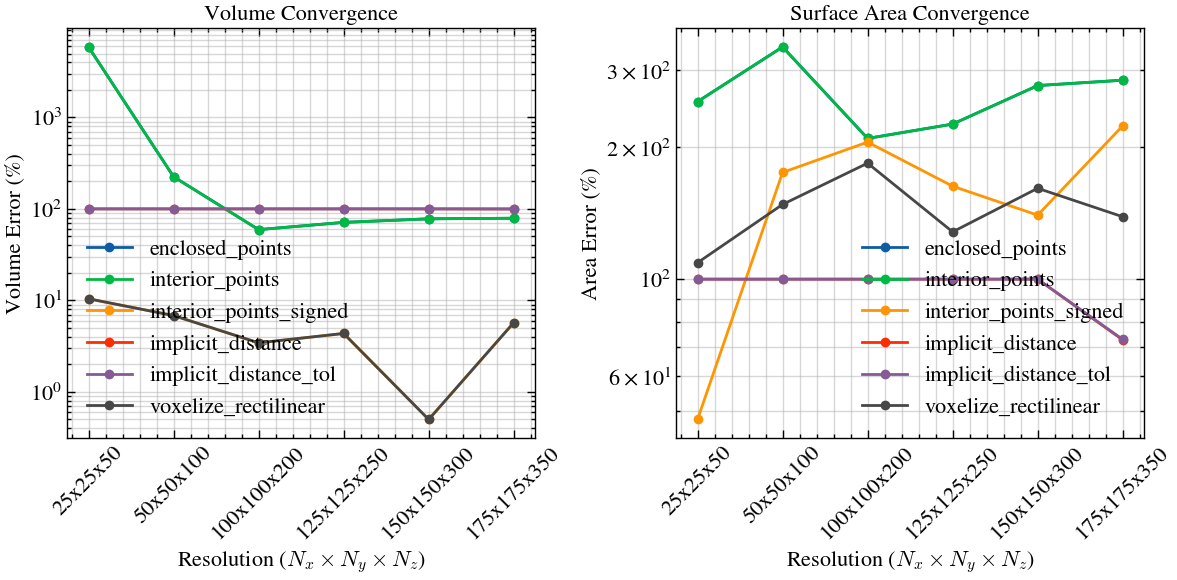

In [9]:

with open('clara_pvMesh_bench_finger_res_1.pkl', 'rb') as f:
    results_finger1= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger1.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

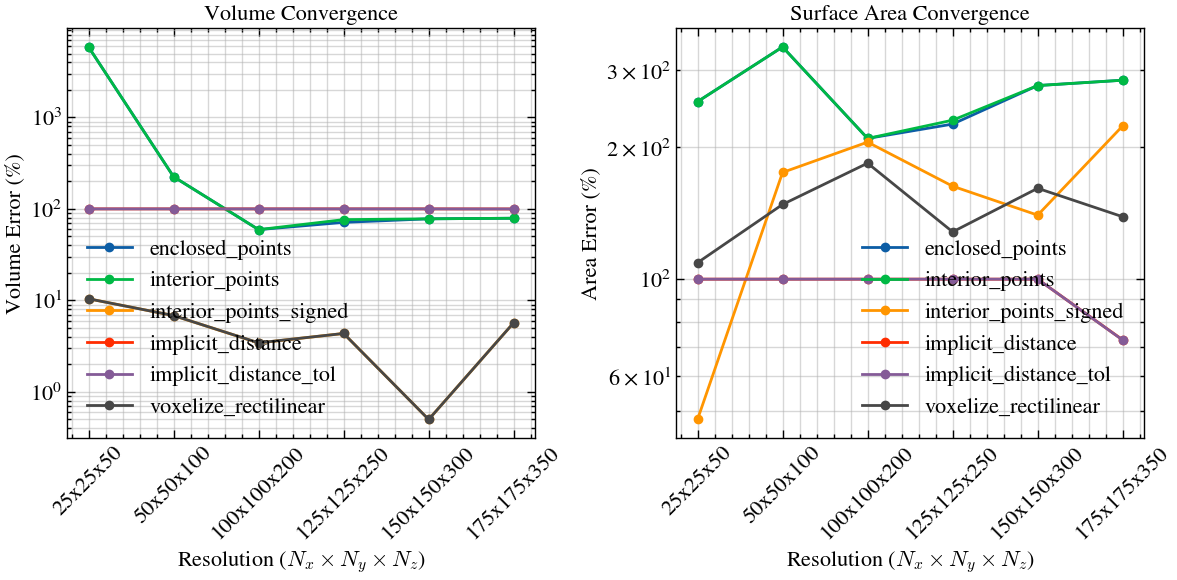

In [ ]:

with open('clara_pvMesh_bench_finger_res_2.pkl', 'rb') as f:
    results_finger2= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger2.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()